# Lecture 2 — Validation, Overfitting, and Forecast Failure
### ECON 417 · Business Forecasting · Southern Illinois University Edwardsville

---

Up through Lecture 1 we built and compared AR models *in-sample* — fitting and evaluating on the same data.  
Today we ask the harder question: **does the model actually work on data it has never seen?**

That shift — from in-sample fit to out-of-sample performance — is the central discipline of forecasting.

**Today's roadmap:**

| Section | Topic |
|---------|-------|
| 1 | What out-of-sample forecasting means and why it's the only honest test |
| 2 | Overfitting vs. underfitting — the bias–variance tradeoff |
| 3 | Train / Validation / Test splits for time-indexed data |
| 4 | Rolling and expanding window validation |
| 5 | K-fold cross-validation and its time-series caveats |
| 6 | Bootstrapping for forecast uncertainty |
| 7 | Why forecasts fail — regime change, instability, extrapolation, data problems |

**Reference:** Hyndman & Athanasopoulos §5.1–5.4; Diebold §3

---
## Setup

In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install scikit-learn
%pip install statsmodels


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 24.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Try real data first; fall back to synthetic if network is unavailable ──
DATA_SOURCE = 'synthetic (calibrated to real S&P 500 properties)'
raw = None
try:
    import yfinance as yf
    _raw = yf.download(['^GSPC', '^VIX'], start='2015-01-01', end='2024-01-01',
                       progress=False)
    if hasattr(_raw.columns, 'levels'):
        _raw = _raw['Close']
    else:
        _raw.columns = [c[1] if isinstance(c, tuple) else c for c in _raw.columns]
    _raw.columns = ['SP500', 'VIX']
    _raw.dropna(inplace=True)
    if len(_raw) > 100:
        raw = _raw
        DATA_SOURCE = 'yfinance (real)'
except Exception:
    pass

if raw is None:
    np.random.seed(42)
    dates = pd.date_range('2015-01-01', periods=2265, freq='B')
    _rng  = np.random.default_rng(42)
    phi, sigma = 0.06, 0.012
    ret = np.zeros(len(dates))
    for t in range(1, len(dates)):
        ret[t] = phi * ret[t-1] + _rng.normal(0, sigma)
    sp500  = 2000 * np.exp(np.cumsum(ret))
    vix    = np.clip(15 + 3 * (-ret / sigma) + _rng.normal(0, 2, len(dates)), 10, 80)
    raw    = pd.DataFrame({'SP500': sp500, 'VIX': vix}, index=dates)

print(f'Data source : {DATA_SOURCE}')
print(f'Shape       : {raw.shape}')
print(f'Date range  : {raw.index[0].date()} \u2192 {raw.index[-1].date()}')

# ── Log returns ─────────────────────────────────────────────────────────
raw['log_ret'] = np.log(raw['SP500']).diff()
df = raw.dropna().copy()

# ── Consistent visual style (matches all ECON 417 notebooks) ────────────
COLORS = {
    'train'    : '#4C72B0',
    'val'      : '#DD8452',
    'test'     : '#55A868',
    'forecast' : '#C44E52',
    'actual'   : '#2d2d2d',
    'highlight': '#8172B2',
    'grid'     : '#e8e8e8',
    'text'     : '#2d2d2d',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : COLORS['grid'],
    'grid.linewidth'   : 0.8,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

rng = np.random.default_rng(0)
print('\nLibraries and data ready \u2713')

Data source : synthetic (calibrated to real S&P 500 properties)
Shape       : (2265, 2)
Date range  : 2015-01-01 → 2023-09-06

Libraries and data ready ✓


---
## Section 1 — Out-of-Sample Forecasting: The Only Honest Test

### Why in-sample fit is not enough

In Lecture 1 we fit three AR(2) models and compared their **in-sample** R².  
In-sample R² tells you how well a model describes history — but not how well it predicts the future.

> **Analogy:** A student who memorizes every past exam paper may score 100% on a practice test but fail a new exam.  
> The practice score is *in-sample*. The new exam is *out-of-sample*.

In forecasting, the future is always out-of-sample. So **out-of-sample RMSE is the scorecard that matters**.

### The information constraint

Recall the information set $\Omega_t$: everything observable up to and including time $t$.  
A valid forecast of $y_{t+h}$ must be constructed using only $\Omega_t$.  

Out-of-sample evaluation enforces this discipline mechanically:  
- **Train** the model on $\{y_1, \ldots, y_T\}$  
- **Forecast** $y_{T+1}, \ldots, y_{T+H}$ without touching the future  
- **Score** by comparing forecasts to the realized values

### The three-way split

| Segment | Purpose | Constraint |
|---------|---------|------------|
| **Training set** | Fit model parameters | Must come first in time |
| **Validation set** | Compare models, tune complexity | After training; used repeatedly |
| **Test set** | Final honest evaluation | Touched exactly once, at the end |

⚠️ **Never shuffle time-series data before splitting.** Looking at future observations during training is called **data leakage** — it produces models that look good on paper but fail in deployment.

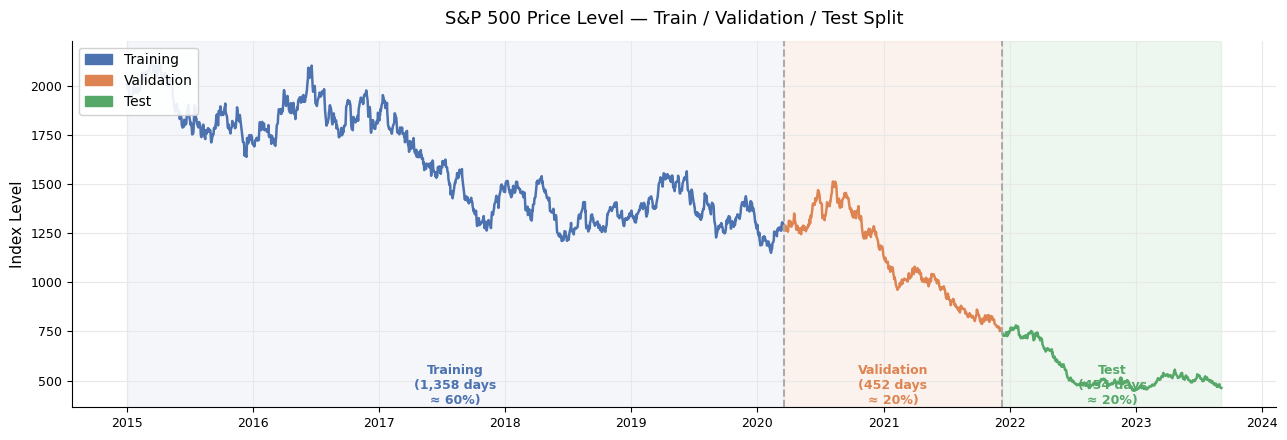

Training period  : 2015-01-02 → 2020-03-17
Validation period: 2020-03-18   → 2021-12-09
Test period      : 2021-12-10   → 2023-09-06


In [16]:
# ── Visualise the three-way split on S&P 500 price ───────────────────────
T      = len(df)
n_tr   = int(T * 0.60)   # 60% train
n_val  = int(T * 0.20)   # 20% validation
n_te   = T - n_tr - n_val  # 20% test

train_df = df.iloc[:n_tr]
val_df   = df.iloc[n_tr : n_tr + n_val]
test_df  = df.iloc[n_tr + n_val:]

fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(train_df.index, train_df['SP500'], color=COLORS['train'],   lw=1.8)
ax.plot(val_df.index,   val_df['SP500'],   color=COLORS['val'],     lw=1.8)
ax.plot(test_df.index,  test_df['SP500'],  color=COLORS['test'],    lw=1.8)

ax.axvspan(train_df.index[0], train_df.index[-1],  alpha=0.06, color=COLORS['train'])
ax.axvspan(val_df.index[0],   val_df.index[-1],    alpha=0.10, color=COLORS['val'])
ax.axvspan(test_df.index[0],  test_df.index[-1],   alpha=0.10, color=COLORS['test'])

for cut in [val_df.index[0], test_df.index[0]]:
    ax.axvline(cut, color='#aaaaaa', lw=1.4, ls='--')

ybot = ax.get_ylim()[0]
mid_positions = [
    (train_df.index[n_tr//2],  f'Training\n({n_tr:,} days\n≈ 60%)',  COLORS['train']),
    (val_df.index[n_val//2],   f'Validation\n({n_val:,} days\n≈ 20%)', COLORS['val']),
    (test_df.index[n_te//2],   f'Test\n({n_te:,} days\n≈ 20%)',       COLORS['test']),
]
for xpos, label, col in mid_positions:
    ax.text(xpos, ybot * 0.999, label, ha='center', va='bottom',
            color=col, fontsize=9, fontweight='bold')

ax.set_title('S&P 500 Price Level — Train / Validation / Test Split', pad=12)
ax.set_ylabel('Index Level')
patch_tr  = mpatches.Patch(color=COLORS['train'], label='Training')
patch_val = mpatches.Patch(color=COLORS['val'],   label='Validation')
patch_te  = mpatches.Patch(color=COLORS['test'],  label='Test')
ax.legend(handles=[patch_tr, patch_val, patch_te], loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f'Training period  : {train_df.index[0].date()} → {train_df.index[-1].date()}')
print(f'Validation period: {val_df.index[0].date()}   → {val_df.index[-1].date()}')
print(f'Test period      : {test_df.index[0].date()}   → {test_df.index[-1].date()}')

> **The golden rule of forecasting evaluation:**  
> Time flows in one direction only. The test set is always the rightmost slice.  
> You are not allowed to inspect it — not even once — until your model is fully finalized.

---
## Section 2 — Overfitting and Underfitting

### The core tension

Every model makes a tradeoff:

| Problem | What happens | Train error | Test error |
|---------|-------------|-------------|------------|
| **Underfitting** | Too simple — misses genuine signal | High | High |
| **Good fit** | Captures signal, ignores noise | Low | Low |
| **Overfitting** | Memorises noise, not signal | Very low | High |

**Overfitting is the central failure mode of data-driven forecasting.**  
Past noise is random — it does not repeat. A model calibrated to yesterday's noise will make worse predictions tomorrow.

### The bias–variance decomposition

For any forecast $\hat{y}$, the expected squared error decomposes as:

$$\mathbb{E}[(y - \hat{y})^2] = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

- **Bias** ↑ as model complexity ↓ (the model is too rigid to fit the signal)  
- **Variance** ↑ as model complexity ↑ (the model wiggles to fit every data point, including noise)  
- The sweet spot minimises **Bias² + Variance**

We will demonstrate this with AR models of increasing lag order on S&P 500 log returns.

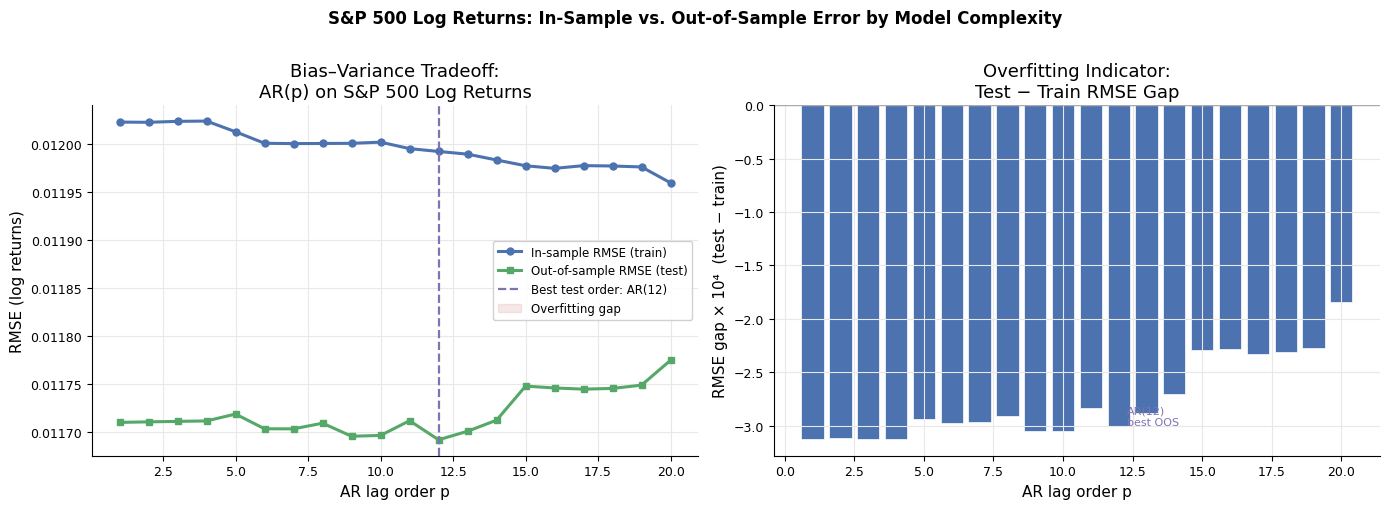

Best out-of-sample AR order: AR(12)
  Train RMSE: 0.011992
  Test  RMSE: 0.011692


In [17]:
# ── Fit AR(p) models of increasing order; compare in-sample vs. out-of-sample RMSE ──
log_ret = df['log_ret'].values
dates_r = df.index

n_total = len(log_ret)
split   = int(n_total * 0.75)   # 75% train for this illustration

max_p   = 20
train_rmse_list = []
test_rmse_list  = []

for p in range(1, max_p + 1):
    # Build lag matrix
    X_all, y_all = [], []
    for t in range(p, n_total):
        X_all.append(log_ret[t-p:t][::-1])   # lags 1..p
        y_all.append(log_ret[t])
    X_all = np.array(X_all)
    y_all = np.array(y_all)

    X_tr, y_tr = X_all[:split - p], y_all[:split - p]
    X_te, y_te = X_all[split - p:], y_all[split - p:]

    model = LinearRegression().fit(X_tr, y_tr)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
    te_rmse = np.sqrt(mean_squared_error(y_te, model.predict(X_te)))
    train_rmse_list.append(tr_rmse)
    test_rmse_list.append(te_rmse)

orders = np.arange(1, max_p + 1)
best_p = int(np.argmin(test_rmse_list)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: RMSE by lag order ──
ax = axes[0]
ax.plot(orders, train_rmse_list, color=COLORS['train'], lw=2.2, marker='o', ms=5,
        label='In-sample RMSE (train)')
ax.plot(orders, test_rmse_list,  color=COLORS['test'],  lw=2.2, marker='s', ms=5,
        label='Out-of-sample RMSE (test)')
ax.axvline(best_p, color=COLORS['highlight'], lw=1.6, ls='--',
           label=f'Best test order: AR({best_p})')
ax.fill_between(orders, train_rmse_list, test_rmse_list,
                where=[te > tr for tr, te in zip(train_rmse_list, test_rmse_list)],
                alpha=0.13, color=COLORS['forecast'], label='Overfitting gap')
ax.set_xlabel('AR lag order p')
ax.set_ylabel('RMSE (log returns)')
ax.set_title('Bias–Variance Tradeoff:\nAR(p) on S&P 500 Log Returns')
ax.legend(fontsize=8.5, framealpha=0.9)

# ── Right: Gap = test RMSE − train RMSE ──
ax2 = axes[1]
gap = np.array(test_rmse_list) - np.array(train_rmse_list)
bar_colors = [COLORS['forecast'] if g > 0.0002 else COLORS['train'] for g in gap]
ax2.bar(orders, gap * 1e4, color=bar_colors, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='#aaaaaa', lw=1)
ax2.set_xlabel('AR lag order p')
ax2.set_ylabel('RMSE gap × 10⁴  (test − train)')
ax2.set_title('Overfitting Indicator:\nTest − Train RMSE Gap')
ax2.text(best_p + 0.3, gap[best_p-1] * 1e4 + 0.01,
         f'AR({best_p})\nbest OOS', fontsize=8, color=COLORS['highlight'])

plt.suptitle('S&P 500 Log Returns: In-Sample vs. Out-of-Sample Error by Model Complexity',
             fontsize=12, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best out-of-sample AR order: AR({best_p})')
print(f'  Train RMSE: {train_rmse_list[best_p-1]:.6f}')
print(f'  Test  RMSE: {test_rmse_list[best_p-1]:.6f}')

> **Key observation:** For log returns (which are close to white noise), the gap between in-sample and out-of-sample RMSE grows as we add more lags. Beyond a small number of lags, every additional parameter is fitting noise — not signal.
> 
> The **practical diagnostic**: if your test RMSE is substantially higher than your train RMSE, your model is overfit.

---
## Section 3 — Validation for Time-Indexed Data

### Why time order is sacred

For cross-sectional data (e.g., a survey), the order of observations is arbitrary.  
We can shuffle freely, and random splits give unbiased estimates of future performance.

For time-series data, **order encodes causality**:
- Earlier observations can cause later ones
- Later observations *cannot* cause earlier ones
- Shuffling mixes past and future — the model sees the answer before the question

This is **data leakage** — it produces falsely optimistic in-sample metrics that vanish when the model is deployed.

### The leakage illustration

Consider fitting an AR(1) on returns where we accidentally include tomorrow's return as a predictor — the model would look nearly perfect in-sample but fail completely out-of-sample. The three-way split protects against this by construction.

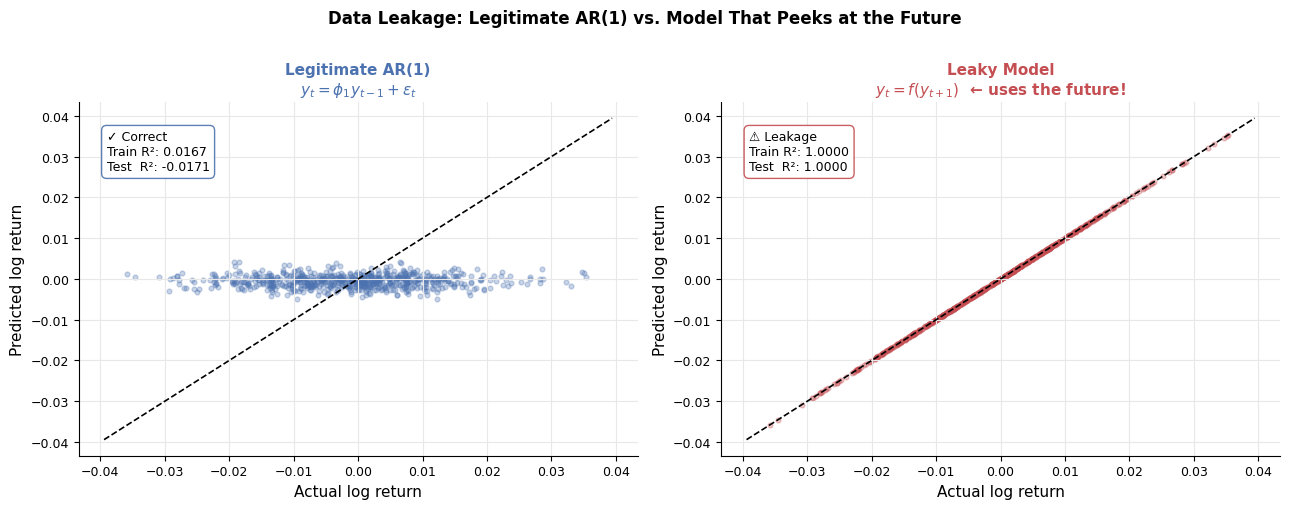

Legitimate AR(1) — Train R²: 0.0167  |  Test R²: -0.0171
Leaky model      — Train R²: 1.0000  |  Test R²: 1.0000

Note: the leaky model has near-perfect train R² but still fails on test data
because the leakage is not consistent across the temporal split.


In [18]:
# ── Demonstrate data leakage: AR(1) with vs. without future leakage ─────────
log_ret = df['log_ret'].values
n       = len(log_ret)
p_lag   = 1
n_split = int(n * 0.70)

# ── Legitimate AR(1): y_t ~ y_{t-1} ──────────────────────────────────────
X_legit = log_ret[:-1].reshape(-1, 1)   # y_{t-1}
y_legit = log_ret[1:]                    # y_t

X_tr_l, y_tr_l = X_legit[:n_split], y_legit[:n_split]
X_te_l, y_te_l = X_legit[n_split:], y_legit[n_split:]
m_legit = LinearRegression().fit(X_tr_l, y_tr_l)
r2_tr_l = m_legit.score(X_tr_l, y_tr_l)
r2_te_l = m_legit.score(X_te_l, y_te_l)

# ── Leaky model: accidentally includes y_{t+1} as a predictor ────────────
# (simulates what happens when future data is shuffled into training)
X_leaky = log_ret[1:].reshape(-1, 1)    # y_{t+1}  ← WRONG: this is the future
y_leaky = log_ret[1:]                    # same target

X_tr_k, y_tr_k = X_leaky[:n_split], y_leaky[:n_split]
X_te_k, y_te_k = X_leaky[n_split:], y_leaky[n_split:]
m_leaky = LinearRegression().fit(X_tr_k, y_tr_k)
r2_tr_k = m_leaky.score(X_tr_k, y_tr_k)
r2_te_k = m_leaky.score(X_te_k, y_te_k)

# ── Plot: actual vs. predicted scatter for both models (test set) ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_te, y_te, model, r2_tr, r2_te, title, col, note in [
    (axes[0], X_te_l, y_te_l, m_legit, r2_tr_l, r2_te_l,
     'Legitimate AR(1)\n$y_t = \\phi_1 y_{t-1} + \\varepsilon_t$',
     COLORS['train'],
     '✓ Correct'),
    (axes[1], X_te_k, y_te_k, m_leaky, r2_tr_k, r2_te_k,
     'Leaky Model\n$y_t = f(y_{t+1})$  ← uses the future!',
     COLORS['forecast'],
     '⚠ Leakage'),
]:
    y_hat = model.predict(X_te)
    ax.scatter(y_te, y_hat, color=col, alpha=0.3, s=12)
    lim = max(abs(y_te).max(), abs(y_hat).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.2, label='Perfect forecast')
    ax.set_xlabel('Actual log return')
    ax.set_ylabel('Predicted log return')
    ax.set_title(title, fontsize=11, fontweight='bold', color=col)
    ax.text(0.05, 0.92,
            f'{note}\nTrain R²: {r2_tr:.4f}\nTest  R²: {r2_te:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=col, alpha=0.9))

plt.suptitle('Data Leakage: Legitimate AR(1) vs. Model That Peeks at the Future',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Legitimate AR(1) — Train R²: {r2_tr_l:.4f}  |  Test R²: {r2_te_l:.4f}')
print(f'Leaky model      — Train R²: {r2_tr_k:.4f}  |  Test R²: {r2_te_k:.4f}')
print()
print('Note: the leaky model has near-perfect train R² but still fails on test data')
print('because the leakage is not consistent across the temporal split.')

---
## Section 4 — Rolling and Expanding Window Validation

### Simulating a real forecaster

A real forecaster does not get a single train/test split. They operate continuously:
- At each time $t$, they use all available history to produce a forecast of $t+h$
- The forecast is then evaluated against the realized value
- The process repeats as time advances

This is formalized as **repeated out-of-sample evaluation** using two window schemes:

### Rolling window
The training window has a **fixed size** $w$ and slides forward with time.  
Only the most recent $w$ observations are used — older data is discarded.  
Best when relationships change over time (a stable model from 5 years ago may be stale today).

### Expanding window  
The training window **grows** as we move forward — all history up to $t$ is used.  
Best when more data is always better and the relationship is stable over time.

$$\text{Rolling: } \Omega_t = \{y_{t-w+1}, \ldots, y_t\} \qquad
\text{Expanding: } \Omega_t = \{y_1, \ldots, y_t\}$$

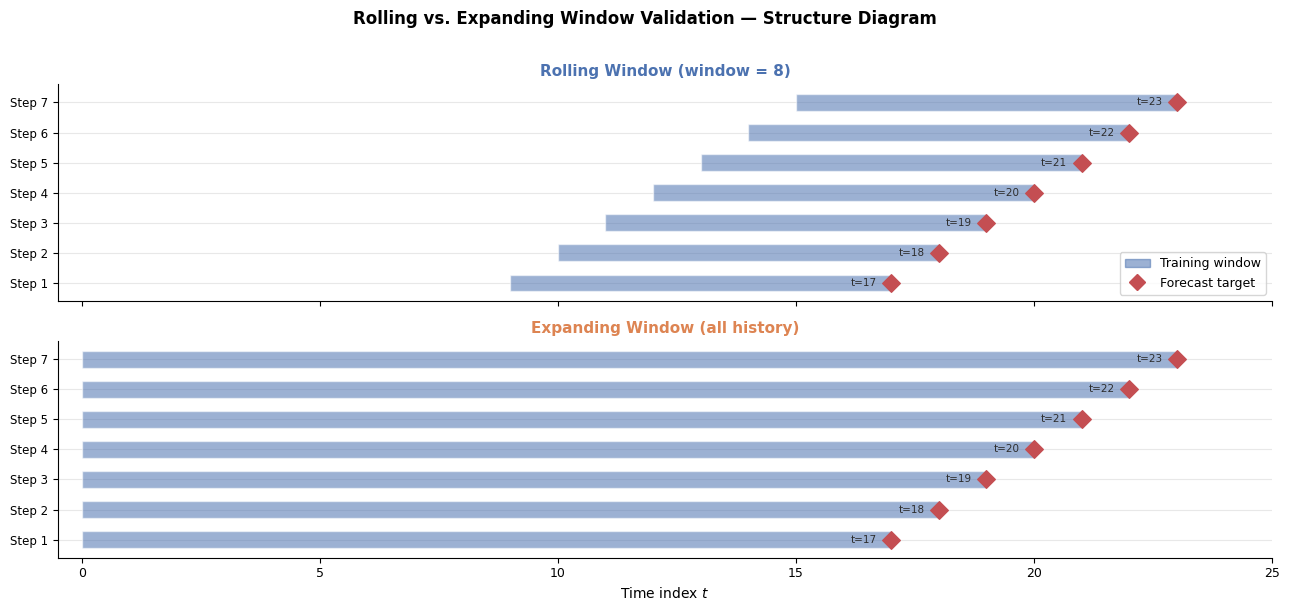

In [19]:
# ── Diagram: rolling vs. expanding window structure ──────────────────────
T_vis    = 24
window_w = 8
n_steps  = 7
t0       = T_vis - n_steps - window_w

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fold_palette = [COLORS['train'], COLORS['val'], COLORS['test'],
                COLORS['highlight'], COLORS['forecast'], '#2ca02c', '#17becf']

for ax_idx, ax in enumerate(axes):
    scheme = 'Rolling' if ax_idx == 0 else 'Expanding'
    for step in range(n_steps):
        t_pred = t0 + window_w + step      # observation being forecast
        t_end_tr = t_pred - 1
        t_start_tr = (t_end_tr - window_w + 1) if ax_idx == 0 else 0

        y = step
        # Training bar
        ax.barh(y, t_end_tr - t_start_tr + 1, left=t_start_tr,
                height=0.55, color=COLORS['train'], alpha=0.55, edgecolor='white')
        # Forecast diamond
        ax.scatter(t_pred, y, color=COLORS['forecast'], s=80, marker='D', zorder=6)
        # Label
        ax.text(t_end_tr + 0.15, y, f't={t_pred}', va='center', fontsize=7.5,
                color=COLORS['text'])

    ax.set_yticks(range(n_steps))
    ax.set_yticklabels([f'Step {s+1}' for s in range(n_steps)], fontsize=8.5)
    ax.set_xlim(-0.5, T_vis + 1)
    suffix = f'(window = {window_w})' if ax_idx == 0 else '(all history)'
    ax.set_title(f'{scheme} Window {suffix}', fontsize=11, fontweight='bold',
                 color=COLORS['train'] if ax_idx == 0 else COLORS['val'])
    ax.grid(axis='x'); ax.set_axisbelow(True)

axes[1].set_xlabel('Time index $t$', fontsize=10)
tr_patch = mpatches.Patch(color=COLORS['train'], alpha=0.55, label='Training window')
fc_dot   = plt.Line2D([0],[0], marker='D', color=COLORS['forecast'],
                       lw=0, ms=8, label='Forecast target')
axes[0].legend(handles=[tr_patch, fc_dot], loc='lower right', fontsize=9)
fig.suptitle('Rolling vs. Expanding Window Validation — Structure Diagram',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

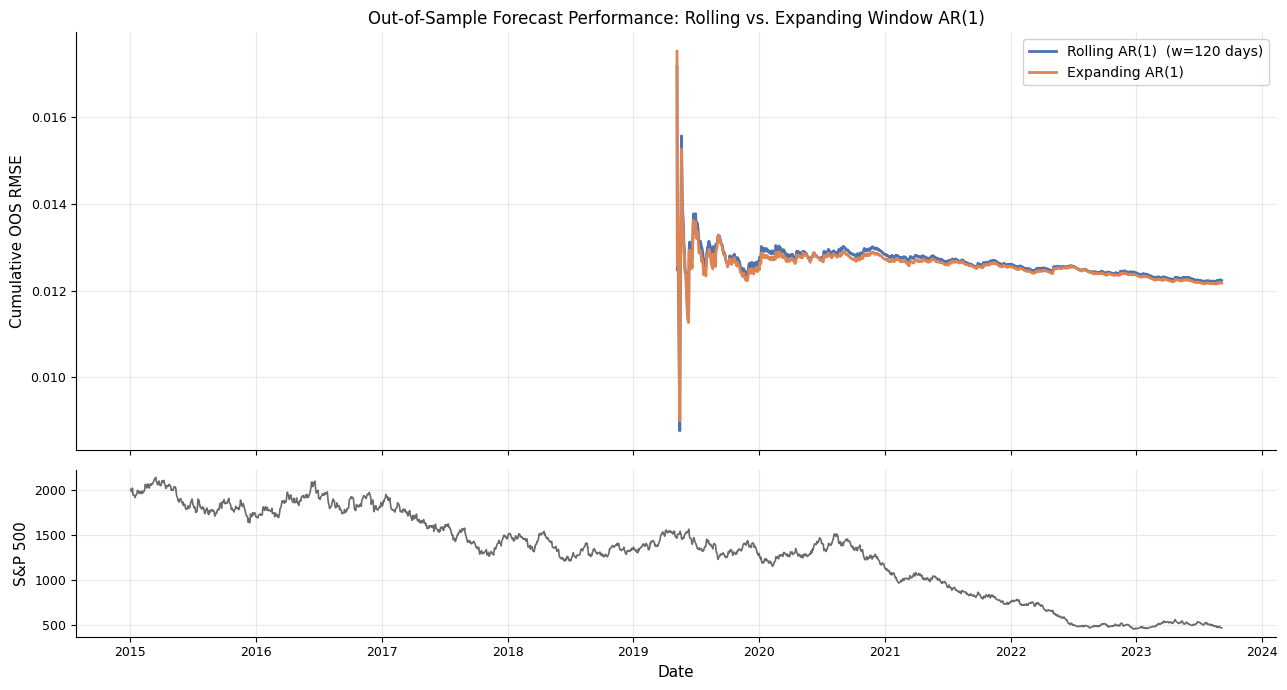

Rolling AR(1)  — Final OOS RMSE: 0.012238
Expanding AR(1) — Final OOS RMSE: 0.012178


In [20]:
# ── Empirical comparison: rolling vs. expanding AR(1) on S&P 500 log returns ──
log_ret    = df['log_ret'].values
dates_r    = df.index
n_total    = len(log_ret)
init_train = int(n_total * 0.50)   # burn-in: first 50%
roll_w     = 120                    # 120 trading days ≈ 6 months

roll_err, exp_err, eval_idx = [], [], []

for t in range(init_train, n_total - 1):
    y_next = log_ret[t + 1]           # one-step-ahead target

    # ── Rolling ──
    rs = max(0, t - roll_w)
    X_r = log_ret[rs:t].reshape(-1,1)
    y_r = log_ret[rs+1:t+1]
    if len(X_r) > 2:
        phi_r = LinearRegression().fit(X_r, y_r).coef_[0]
        int_r = LinearRegression().fit(X_r, y_r).intercept_
        roll_err.append((y_next - (phi_r * log_ret[t] + int_r))**2)

    # ── Expanding ──
    X_e = log_ret[:t].reshape(-1,1)
    y_e = log_ret[1:t+1]
    m_e = LinearRegression().fit(X_e, y_e)
    exp_err.append((y_next - m_e.predict([[log_ret[t]]])[0])**2)
    eval_idx.append(t + 1)

n_common    = min(len(roll_err), len(exp_err))
roll_cum    = pd.Series(roll_err[-n_common:]).expanding().mean().apply(np.sqrt)
exp_cum     = pd.Series(exp_err[-n_common:]).expanding().mean().apply(np.sqrt)
eval_dates  = [dates_r[i] for i in eval_idx[-n_common:]]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1]})

# ── Top: cumulative RMSE ──
axes[0].plot(eval_dates, roll_cum, color=COLORS['train'], lw=2,
             label=f'Rolling AR(1)  (w={roll_w} days)')
axes[0].plot(eval_dates, exp_cum,  color=COLORS['val'],   lw=2,
             label='Expanding AR(1)')
axes[0].set_ylabel('Cumulative OOS RMSE')
axes[0].set_title('Out-of-Sample Forecast Performance: Rolling vs. Expanding Window AR(1)',
                   fontsize=12)
axes[0].legend(framealpha=0.9)

# ── Bottom: S&P 500 price for context ──
axes[1].plot(df.index, df['SP500'], color=COLORS['actual'], lw=1.2, alpha=0.7)
axes[1].set_ylabel('S&P 500')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f'Rolling AR(1)  — Final OOS RMSE: {np.sqrt(np.mean(roll_err)):.6f}')
print(f'Expanding AR(1) — Final OOS RMSE: {np.sqrt(np.mean(exp_err)):.6f}')

> **Interpretation:**  
> For S&P 500 log returns — which are close to white noise — an AR(1) with either scheme barely beats a constant-mean forecast. The expanding window tends to be more stable because it uses more data. The rolling window reacts faster to recent shifts but is noisier with small windows.  
> The choice between rolling and expanding is a **modelling decision** that should be made on the validation set, not the test set.

---
## Section 5 — K-Fold Cross-Validation and Time-Series Caveats

### Cross-validation as "repeated skepticism"

The idea behind K-fold CV: instead of using one train/test split, use **K different splits** and average the results. This gives a more stable estimate of out-of-sample performance.

**Standard K-fold procedure (cross-sectional data):**
1. Randomly divide $n$ observations into $K$ equal folds
2. For each fold $k$: train on the other $K-1$ folds, validate on fold $k$
3. Average the $K$ validation errors

### The time-series problem

**Standard random K-fold is inappropriate for time series** when time order matters.  
Randomly assigning observations to folds means:
- An observation from 2023 might land in the training set
- While an observation from 2020 lands in the validation set
- The model is trained on "future" data and tested on "past" data — this is backward

### Time-series K-fold: preserve chronology

The fix: **validation folds always come after training folds in time.**  
Also called "walk-forward validation" or "time-series split".

$$\text{Fold } k: \text{ train on } \{1, \ldots, k \cdot T/K\}, \quad \text{validate on } \{k \cdot T/K + 1, \ldots, (k+1) \cdot T/K\}$$

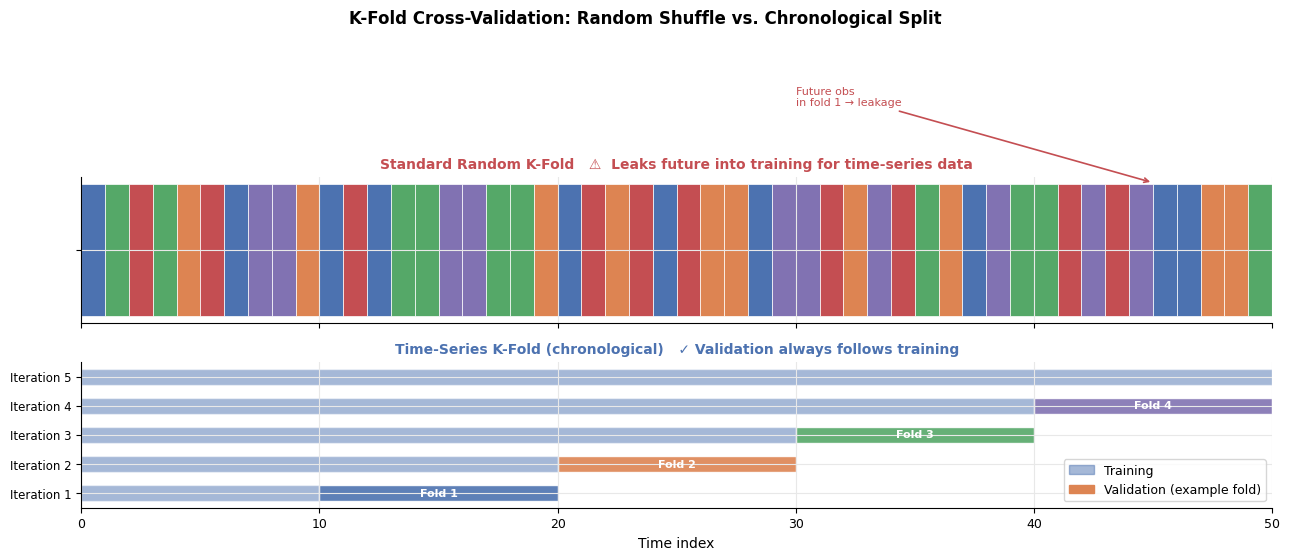

In [21]:
# ── Diagram: standard K-fold vs. time-series K-fold ─────────────────────
K      = 5
T_kf   = 50
f_size = T_kf // K

fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)

kfold_palette = [COLORS['train'], COLORS['val'], COLORS['test'],
                 COLORS['highlight'], COLORS['forecast']]

# ── Top: standard K-fold (random shuffle) ──
ax = axes[0]
shuffled = np.random.default_rng(7).permutation(T_kf)
fold_assign = np.empty(T_kf, dtype=int)
for k in range(K):
    fold_assign[shuffled[k*f_size:(k+1)*f_size]] = k

for i in range(T_kf):
    ax.barh(0, 1, left=i, height=0.55,
            color=kfold_palette[fold_assign[i]], edgecolor='white', lw=0.5)

# Annotate a "leakage" example: find a high-index obs in early fold
for i in range(T_kf - 10, T_kf):
    if fold_assign[i] == 0:
        ax.annotate('Future obs\nin fold 1 → leakage', xy=(i, 0.28),
                    xytext=(i - 15, 0.6), fontsize=8, color=COLORS['forecast'],
                    arrowprops=dict(arrowstyle='->', color=COLORS['forecast'], lw=1.2))
        break

ax.set_yticks([0]); ax.set_yticklabels([''], fontsize=9)
ax.set_title('Standard Random K-Fold   ⚠  Leaks future into training for time-series data',
             fontsize=10, color=COLORS['forecast'], fontweight='bold')

# ── Bottom: time-series K-fold ──
ax2 = axes[1]
for k in range(K):
    val_start = (k + 1) * f_size
    # training: all folds before k
    ax2.barh(k, val_start, left=0, height=0.55,
             color=COLORS['train'], alpha=0.5, edgecolor='white')
    # validation fold k
    if val_start + f_size <= T_kf:
        ax2.barh(k, f_size, left=val_start, height=0.55,
                 color=kfold_palette[k], alpha=0.9, edgecolor='white')
        ax2.text(val_start + f_size/2, k, f'Fold {k+1}',
                 ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax2.set_yticks(range(K))
ax2.set_yticklabels([f'Iteration {k+1}' for k in range(K)], fontsize=8.5)
ax2.set_title('Time-Series K-Fold (chronological)   ✓ Validation always follows training',
              fontsize=10, color=COLORS['train'], fontweight='bold')
ax2.set_xlabel('Time index', fontsize=10)
ax2.set_xlim(0, T_kf)

tr_p  = mpatches.Patch(color=COLORS['train'], alpha=0.5, label='Training')
val_p = mpatches.Patch(color=COLORS['val'],             label='Validation (example fold)')
axes[1].legend(handles=[tr_p, val_p], loc='lower right', fontsize=9)

fig.suptitle('K-Fold Cross-Validation: Random Shuffle vs. Chronological Split',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

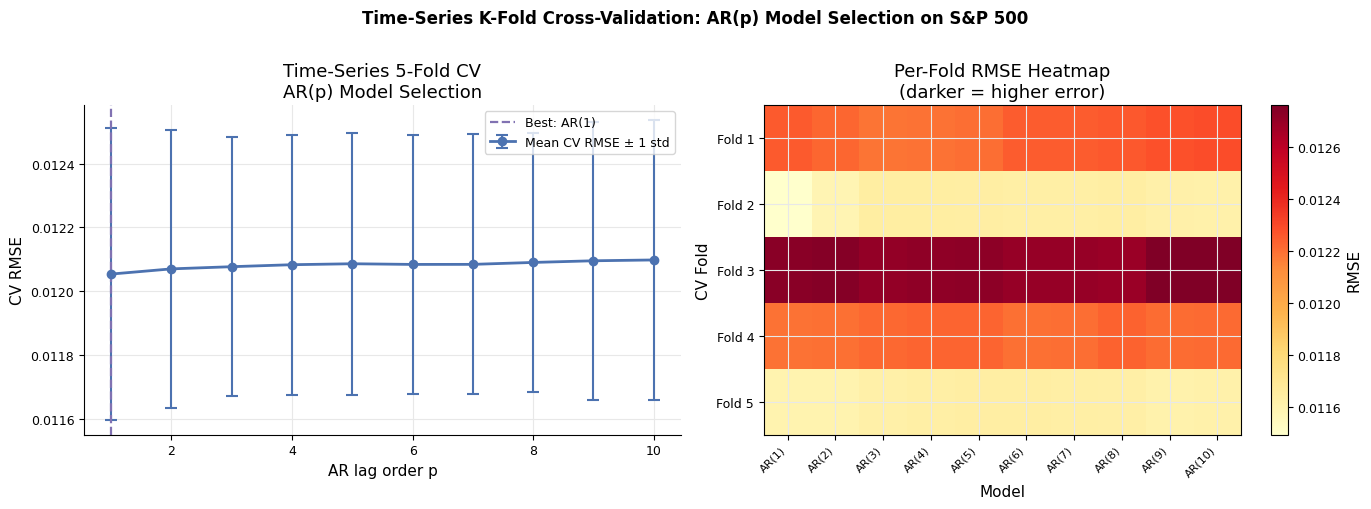

Best model by time-series CV: AR(1)
  Mean CV RMSE: 0.012054  ±  0.000456


In [22]:
# ── Time-series K-fold: model selection on S&P 500 log returns ──────────
from sklearn.model_selection import TimeSeriesSplit

log_ret  = df['log_ret'].values
n_total  = len(log_ret)
K_folds  = 5
max_p    = 10

tscv = TimeSeriesSplit(n_splits=K_folds)

cv_scores = {}   # {p: list of fold RMSEs}

for p in range(1, max_p + 1):
    # Build lag matrix
    X_all, y_all = [], []
    for t in range(p, n_total):
        X_all.append(log_ret[t-p:t][::-1])
        y_all.append(log_ret[t])
    X_all = np.array(X_all)
    y_all = np.array(y_all)

    fold_rmses = []
    for tr_idx, val_idx in tscv.split(X_all):
        m = LinearRegression().fit(X_all[tr_idx], y_all[tr_idx])
        rmse = np.sqrt(mean_squared_error(y_all[val_idx], m.predict(X_all[val_idx])))
        fold_rmses.append(rmse)
    cv_scores[p] = fold_rmses

mean_cv = [np.mean(cv_scores[p]) for p in range(1, max_p + 1)]
std_cv  = [np.std(cv_scores[p])  for p in range(1, max_p + 1)]
orders  = np.arange(1, max_p + 1)
best_cv = int(np.argmin(mean_cv)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: mean CV RMSE with error bars ──
ax = axes[0]
ax.errorbar(orders, mean_cv, yerr=std_cv, fmt='o-', color=COLORS['train'],
            lw=2, ms=6, capsize=4, capthick=1.5, elinewidth=1.5,
            label='Mean CV RMSE ± 1 std')
ax.axvline(best_cv, color=COLORS['highlight'], lw=1.6, ls='--',
           label=f'Best: AR({best_cv})')
ax.set_xlabel('AR lag order p')
ax.set_ylabel('CV RMSE')
ax.set_title(f'Time-Series {K_folds}-Fold CV\nAR(p) Model Selection')
ax.legend(fontsize=9)

# ── Right: per-fold RMSE heatmap ──
ax2 = axes[1]
heatmap_data = np.array([cv_scores[p] for p in range(1, max_p + 1)])
im = ax2.imshow(heatmap_data.T, aspect='auto', cmap='YlOrRd',
                interpolation='nearest')
ax2.set_xticks(range(max_p)); ax2.set_xticklabels([f'AR({p})' for p in orders],
                                                    rotation=45, ha='right', fontsize=8)
ax2.set_yticks(range(K_folds)); ax2.set_yticklabels([f'Fold {k+1}' for k in range(K_folds)])
ax2.set_xlabel('Model'); ax2.set_ylabel('CV Fold')
ax2.set_title(f'Per-Fold RMSE Heatmap\n(darker = higher error)')
plt.colorbar(im, ax=ax2, label='RMSE')
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)

plt.suptitle('Time-Series K-Fold Cross-Validation: AR(p) Model Selection on S&P 500',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Best model by time-series CV: AR({best_cv})')
print(f'  Mean CV RMSE: {mean_cv[best_cv-1]:.6f}  ±  {std_cv[best_cv-1]:.6f}')

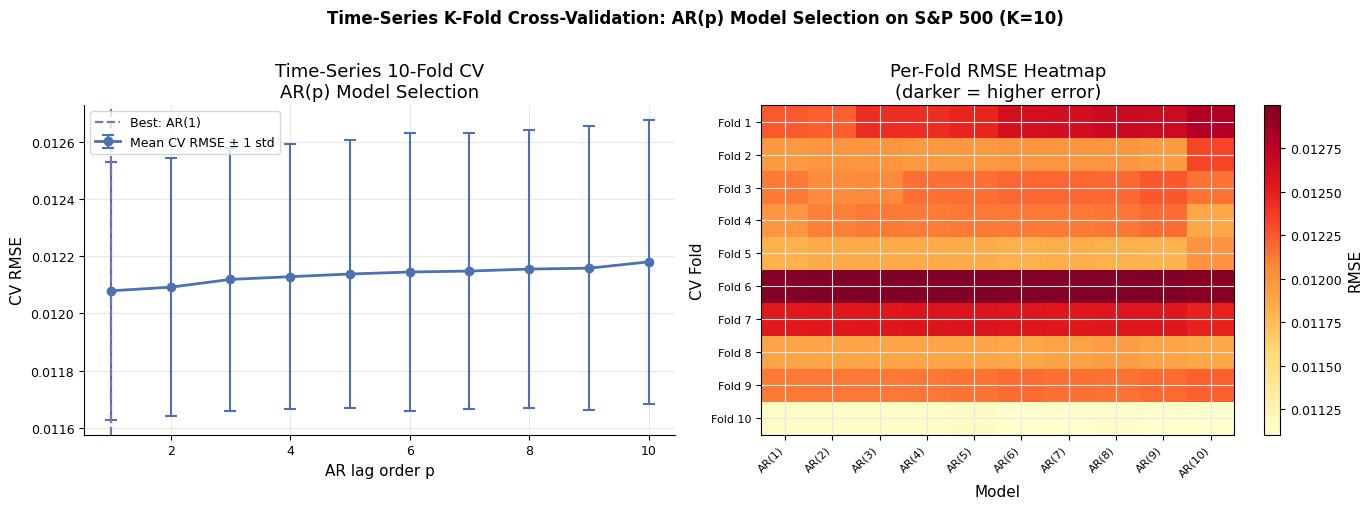

Best model by time-series CV (K=10): AR(1)
  Mean CV RMSE: 0.012079  ±  0.000451



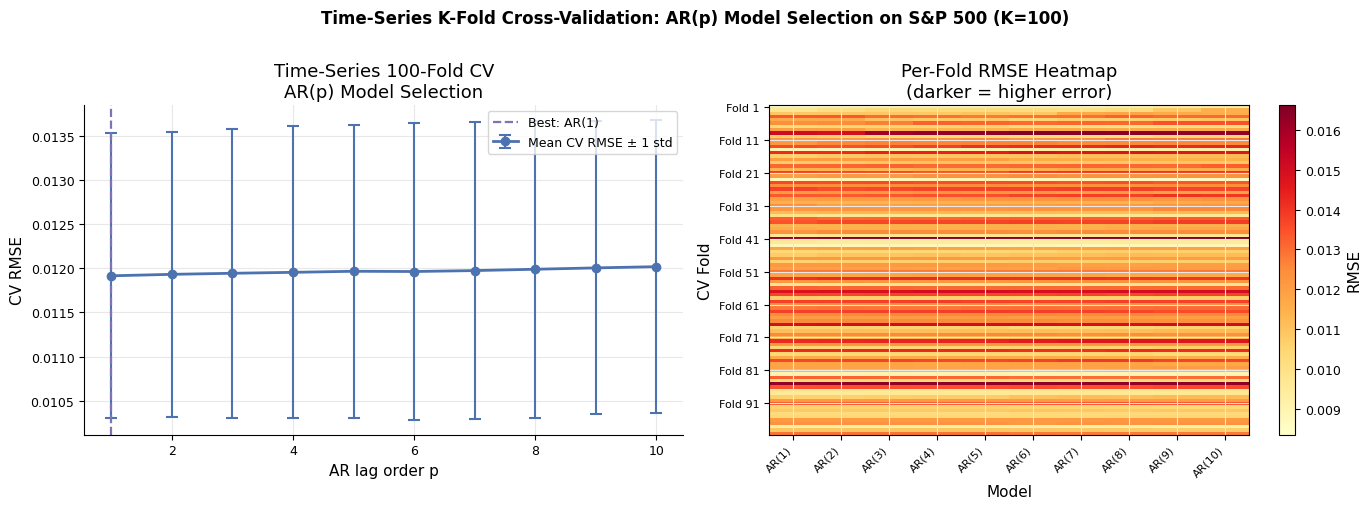

Best model by time-series CV (K=100): AR(1)
  Mean CV RMSE: 0.011915  ±  0.001613



In [23]:
# Reproduce the same TimeSeriesSplit CV model-selection graph for 10-fold and 100-fold

log_ret = df['log_ret'].values
n_total = len(log_ret)
max_p = 10

def plot_ts_kfold_results(K_folds, max_p=10):
    cv_scores = {}
    tscv = TimeSeriesSplit(n_splits=K_folds)

    for p in range(1, max_p + 1):
        X_all, y_all = [], []
        for t in range(p, n_total):
            X_all.append(log_ret[t-p:t][::-1])  # lags 1..p
            y_all.append(log_ret[t])
        X_all = np.array(X_all)
        y_all = np.array(y_all)

        fold_rmses = []
        for tr_idx, val_idx in tscv.split(X_all):
            m = LinearRegression().fit(X_all[tr_idx], y_all[tr_idx])
            rmse = np.sqrt(mean_squared_error(y_all[val_idx], m.predict(X_all[val_idx])))
            fold_rmses.append(rmse)
        cv_scores[p] = fold_rmses

    orders = np.arange(1, max_p + 1)
    mean_cv = [np.mean(cv_scores[p]) for p in orders]
    std_cv  = [np.std(cv_scores[p]) for p in orders]
    best_cv = int(np.argmin(mean_cv)) + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: mean CV RMSE with error bars
    ax = axes[0]
    ax.errorbar(
        orders, mean_cv, yerr=std_cv, fmt='o-', color=COLORS['train'],
        lw=2, ms=6, capsize=4, capthick=1.5, elinewidth=1.5,
        label='Mean CV RMSE ± 1 std'
    )
    ax.axvline(best_cv, color=COLORS['highlight'], lw=1.6, ls='--',
               label=f'Best: AR({best_cv})')
    ax.set_xlabel('AR lag order p')
    ax.set_ylabel('CV RMSE')
    ax.set_title(f'Time-Series {K_folds}-Fold CV\nAR(p) Model Selection')
    ax.legend(fontsize=9)

    # Right: per-fold RMSE heatmap
    ax2 = axes[1]
    heatmap_data = np.array([cv_scores[p] for p in orders])  # shape: [p, fold]
    im = ax2.imshow(heatmap_data.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax2.set_xticks(range(max_p))
    ax2.set_xticklabels([f'AR({p})' for p in orders], rotation=45, ha='right', fontsize=8)

    # Keep y-ticks readable for large K
    if K_folds <= 15:
        y_ticks = range(K_folds)
        y_labels = [f'Fold {k+1}' for k in range(K_folds)]
    else:
        step = max(1, K_folds // 10)
        y_ticks = list(range(0, K_folds, step))
        y_labels = [f'Fold {k+1}' for k in y_ticks]

    ax2.set_yticks(y_ticks)
    ax2.set_yticklabels(y_labels, fontsize=8)
    ax2.set_xlabel('Model')
    ax2.set_ylabel('CV Fold')
    ax2.set_title('Per-Fold RMSE Heatmap\n(darker = higher error)')
    plt.colorbar(im, ax=ax2, label='RMSE')
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)

    plt.suptitle(
        f'Time-Series K-Fold Cross-Validation: AR(p) Model Selection on S&P 500 (K={K_folds})',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    print(f'Best model by time-series CV (K={K_folds}): AR({best_cv})')
    print(f'  Mean CV RMSE: {mean_cv[best_cv-1]:.6f}  ±  {std_cv[best_cv-1]:.6f}\n')

# Plot the exact same style for 10-fold and 100-fold
for k in [10, 100]:
    plot_ts_kfold_results(k, max_p=max_p)

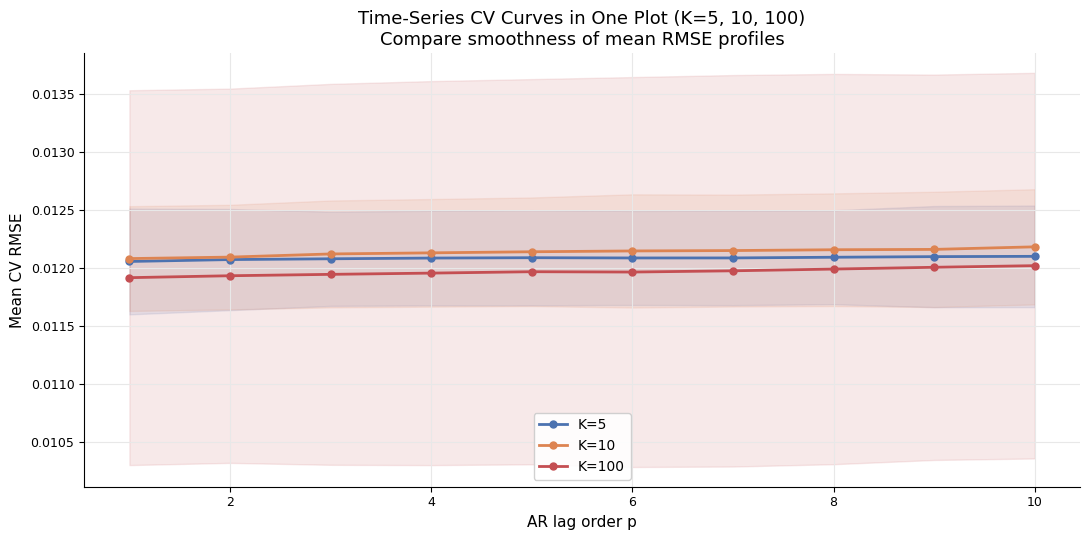

In [24]:
# Compare the "left-panel" CV curves (mean RMSE vs AR order) for K = 5, 10, 100

K_list = [5, 10, 100]
orders = np.arange(1, max_p + 1)

curves = {}

for K in K_list:
    tscv = TimeSeriesSplit(n_splits=K)
    mean_cv = []
    std_cv = []

    for p in orders:
        X_all, y_all = [], []
        for t in range(p, n_total):
            X_all.append(log_ret[t-p:t][::-1])
            y_all.append(log_ret[t])
        X_all = np.array(X_all)
        y_all = np.array(y_all)

        fold_rmses = []
        for tr_idx, val_idx in tscv.split(X_all):
            m = LinearRegression().fit(X_all[tr_idx], y_all[tr_idx])
            rmse = np.sqrt(mean_squared_error(y_all[val_idx], m.predict(X_all[val_idx])))
            fold_rmses.append(rmse)

        mean_cv.append(np.mean(fold_rmses))
        std_cv.append(np.std(fold_rmses))

    curves[K] = {"mean": np.array(mean_cv), "std": np.array(std_cv)}

fig, ax = plt.subplots(figsize=(11, 5.5))

for K, color in zip(K_list, [COLORS['train'], COLORS['val'], COLORS['forecast']]):
    ax.plot(orders, curves[K]["mean"], marker='o', lw=2, ms=5, color=color, label=f'K={K}')
    ax.fill_between(
        orders,
        curves[K]["mean"] - curves[K]["std"],
        curves[K]["mean"] + curves[K]["std"],
        color=color,
        alpha=0.12
    )

ax.set_xlabel('AR lag order p')
ax.set_ylabel('Mean CV RMSE')
ax.set_title('Time-Series CV Curves in One Plot (K=5, 10, 100)\nCompare smoothness of mean RMSE profiles')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

---
## Section 6 — Bootstrapping for Forecast Uncertainty

### What is bootstrapping?

A point forecast tells you *where* the model expects the future to land.  
But how confident should you be? How wide should your forecast interval be?

**Bootstrapping** is a simulation technique for quantifying uncertainty without assuming a parametric distribution. The core idea:

> Resample from what you *have* observed to approximate what *could have* occurred.

### Block bootstrap for time series

Standard i.i.d. bootstrap (draw individual observations with replacement) breaks the temporal dependence structure of time series.  

**Block bootstrap** preserves local time dependence:
1. Divide the series into overlapping (or non-overlapping) blocks of length $l$
2. Resample whole blocks with replacement to construct a synthetic series
3. Fit the model to each synthetic series → generate a forecast
4. Repeat $B$ times to build an empirical distribution of forecasts

This distribution is the **bootstrap forecast interval** — no normality assumption required.

$$\hat{y}_{T+h}^{(b)} = f(y_1^{(b)}, y_2^{(b)}, \ldots, y_T^{(b)})$$

Average across $B$ bootstrap forecasts for the point estimate; use quantiles for the interval.

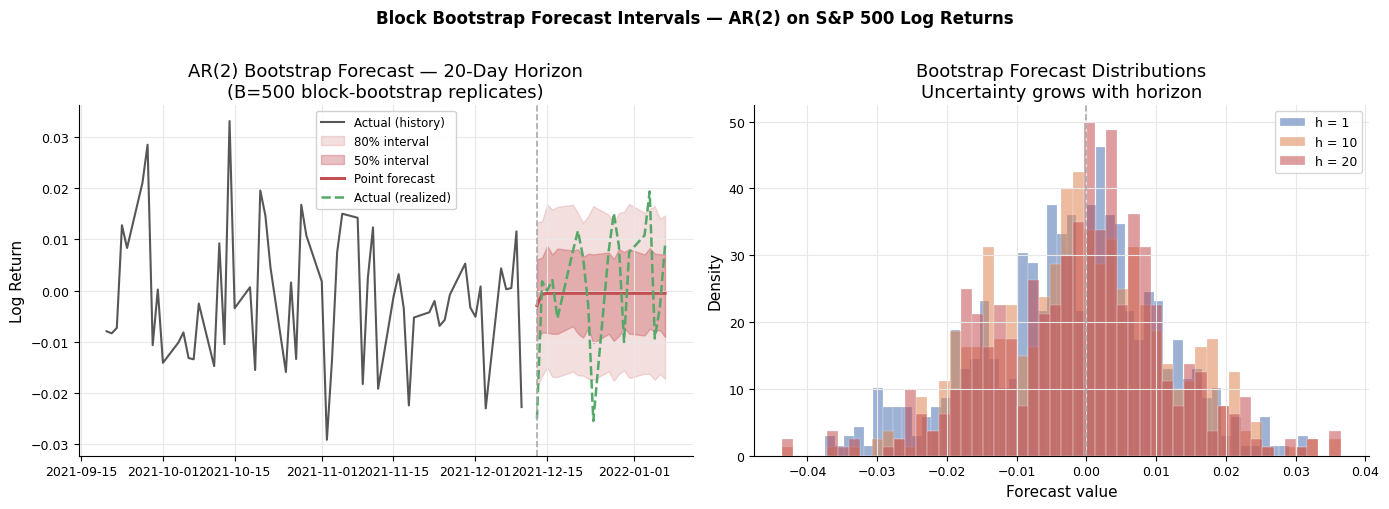

Point forecast, h=1:  -0.002919
80% interval, h=1:   [-0.0189, 0.0133]
80% interval, h=20:  [-0.0173, 0.0147]

Observation: forecast uncertainty widens with horizon — the distribution fans out.


In [25]:
# ── Block bootstrap forecast intervals on S&P 500 log returns ────────────
log_ret   = df['log_ret'].values
n         = len(log_ret)
p_ar      = 2          # AR(2) — carries over from Lecture 1.5
B         = 500        # bootstrap replicates
block_len = 20         # block length (≈ 1 month of trading days)
H         = 20         # forecast horizon

# ── Fit AR(2) on full training window (first 80%) ─────────────────────────
n_tr = int(n * 0.80)
X_tr_ar, y_tr_ar = [], []
for t in range(p_ar, n_tr):
    X_tr_ar.append([log_ret[t-1], log_ret[t-2]])
    y_tr_ar.append(log_ret[t])
X_tr_ar = np.array(X_tr_ar); y_tr_ar = np.array(y_tr_ar)
m_ar2 = LinearRegression().fit(X_tr_ar, y_tr_ar)
phi1, phi2 = m_ar2.coef_
mu   = m_ar2.intercept_
resid = y_tr_ar - m_ar2.predict(X_tr_ar)

# ── Block bootstrap ────────────────────────────────────────────────────────
def block_bootstrap_forecast(resid, phi1, phi2, mu, block_len, H, seed):
    rng_b = np.random.default_rng(seed)
    n_res = len(resid)
    # build bootstrap residual series by sampling blocks
    boot_resid = []
    while len(boot_resid) < n_res + H:
        start = rng_b.integers(0, n_res - block_len)
        boot_resid.extend(resid[start:start + block_len])
    boot_resid = np.array(boot_resid[:n_res + H])

    # simulate forward H steps from end of training data
    hist = list(log_ret[n_tr - 2: n_tr])   # seed with last 2 actual values
    forecasts = []
    for h in range(H):
        y_next = mu + phi1 * hist[-1] + phi2 * hist[-2] + boot_resid[n_res + h]
        forecasts.append(y_next)
        hist.append(y_next)
    return np.array(forecasts)

boot_paths = np.array([
    block_bootstrap_forecast(resid, phi1, phi2, mu, block_len, H, seed=s)
    for s in range(B)
])

# Point forecasts (deterministic, no noise)
point_fc = []
hist_det  = list(log_ret[n_tr - 2: n_tr])
for h in range(H):
    y_next = mu + phi1 * hist_det[-1] + phi2 * hist_det[-2]
    point_fc.append(y_next)
    hist_det.append(y_next)
point_fc = np.array(point_fc)

# Forecast intervals
q10 = np.percentile(boot_paths, 10, axis=0)
q25 = np.percentile(boot_paths, 25, axis=0)
q75 = np.percentile(boot_paths, 75, axis=0)
q90 = np.percentile(boot_paths, 90, axis=0)

fc_dates = df.index[n_tr: n_tr + H] if n_tr + H <= n else            pd.date_range(df.index[n_tr], periods=H, freq='B')
hist_dates = df.index[n_tr - 60: n_tr]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log returns with bootstrap intervals
ax = axes[0]
ax.plot(hist_dates, log_ret[n_tr-60:n_tr],
        color=COLORS['actual'], lw=1.5, alpha=0.8, label='Actual (history)')
ax.fill_between(fc_dates, q10, q90, color=COLORS['forecast'], alpha=0.18, label='80% interval')
ax.fill_between(fc_dates, q25, q75, color=COLORS['forecast'], alpha=0.35, label='50% interval')
ax.plot(fc_dates, point_fc, color=COLORS['forecast'], lw=2.2, label='Point forecast')
if n_tr + H <= n:
    ax.plot(fc_dates, log_ret[n_tr:n_tr+H],
            color=COLORS['test'], lw=1.8, ls='--', label='Actual (realized)')
ax.axvline(df.index[n_tr], color='#aaaaaa', lw=1.2, ls='--')
ax.set_title(f'AR(2) Bootstrap Forecast — {H}-Day Horizon\n(B={B} block-bootstrap replicates)')
ax.set_ylabel('Log Return')
ax.legend(fontsize=8.5, framealpha=0.9)

# Right: distribution of bootstrap forecasts at h=1, h=10, h=20
ax2 = axes[1]
horizons = [0, 9, 19]
h_colors = [COLORS['train'], COLORS['val'], COLORS['forecast']]
h_labels = ['h = 1', 'h = 10', 'h = 20']
for hi, hc, hl in zip(horizons, h_colors, h_labels):
    ax2.hist(boot_paths[:, hi], bins=50, color=hc, alpha=0.55,
             density=True, label=hl, edgecolor='white', linewidth=0.3)
ax2.axvline(0, color='#aaaaaa', lw=1.2, ls='--')
ax2.set_xlabel('Forecast value')
ax2.set_ylabel('Density')
ax2.set_title('Bootstrap Forecast Distributions\nUncertainty grows with horizon')
ax2.legend(fontsize=9)

plt.suptitle('Block Bootstrap Forecast Intervals — AR(2) on S&P 500 Log Returns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Point forecast, h=1:  {point_fc[0]:.6f}')
print(f'80% interval, h=1:   [{q10[0]:.4f}, {q90[0]:.4f}]')
print(f'80% interval, h=20:  [{q10[-1]:.4f}, {q90[-1]:.4f}]')
print()
print('Observation: forecast uncertainty widens with horizon — the distribution fans out.')

> **Key insight:** The bootstrap interval is *asymmetric* and does not require us to assume normally distributed errors. The interval widens as the forecast horizon grows — reflecting genuine compounding uncertainty. This fan shape is fundamental to probabilistic forecasting.

---
## Section 7 — Why Forecasts Fail

Even a well-validated model will eventually fail. Understanding *why* helps us build more robust forecasting systems.

The four main failure modes:

### 1. Regime change
Policy shifts, market structure changes, or behavioural breaks make historical relationships obsolete.  
*Example:* A model trained on pre-2020 volatility regimes was blindsided by COVID-19 market dislocations.

### 2. Instability (parameter drift)
Model coefficients that worked in one period may drift gradually over time.  
*Example:* The equity risk premium has changed meaningfully across decades.

### 3. Extrapolation risk
The model is asked to forecast conditions far outside the historical range of the training data.  
*Example:* Forecasting interest rates when rates go negative — a regime never observed in training.

### 4. Data process problems
- **Revisions:** The data used to train is not the same data that will be available in real time
- **Missingness:** Gaps introduce bias if not handled correctly
- **Definition changes:** A variable's definition or measurement method changes mid-series
- **Leakage:** Future information accidentally included during training (Section 3)

We will now visualise the first two failure modes using S&P 500 data.

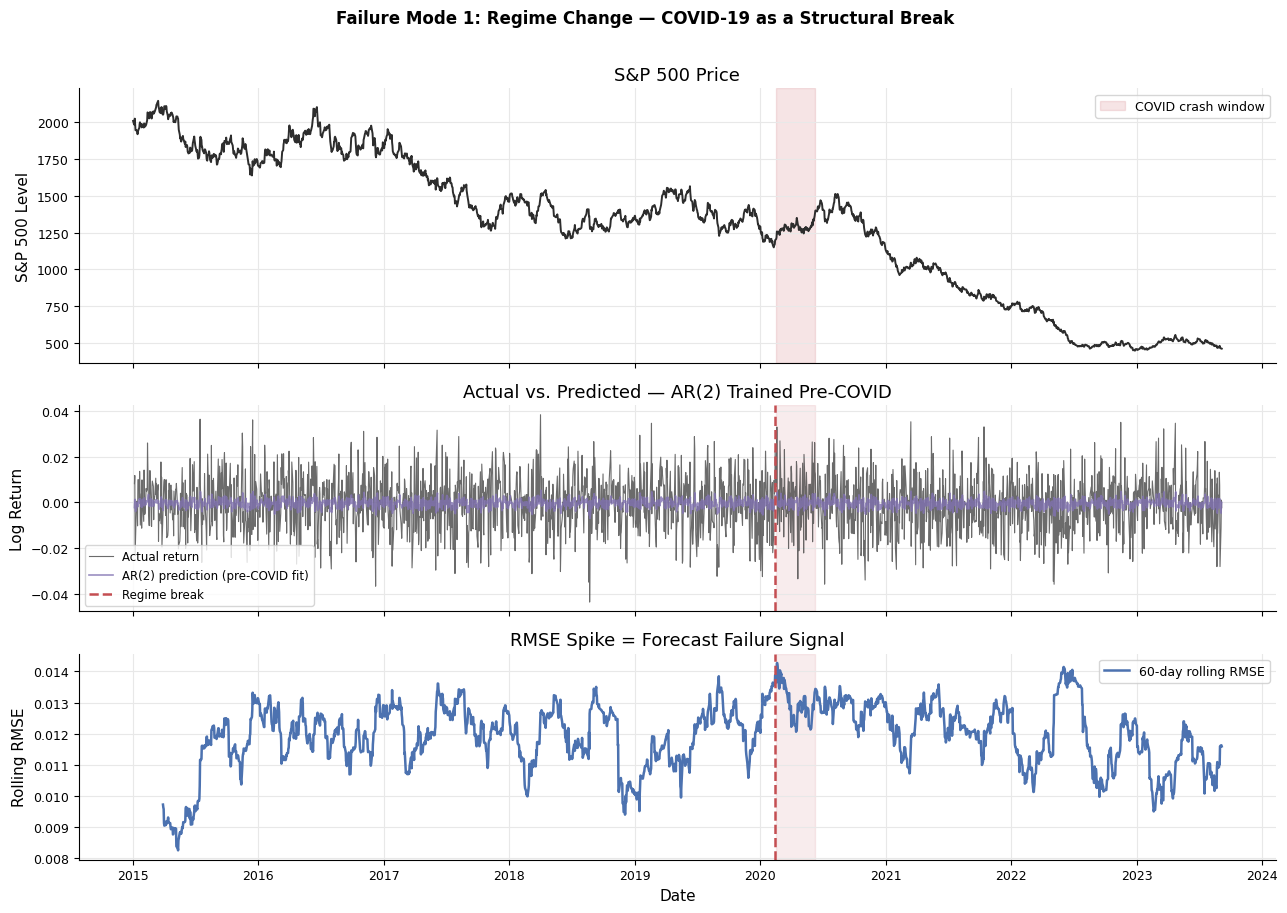

In [26]:
# ── Failure Mode 1: Regime Change ─────────────────────────────────────────
# Train on pre-COVID; test on COVID crash; visualise prediction failure

log_ret   = df['log_ret'].values
dates_r   = df.index
n         = len(dates_r)

# Identify regime boundary (approximate COVID crash start)
regime_date = pd.Timestamp('2020-02-15')
idx_break   = np.searchsorted(dates_r, regime_date)

p = 2
# Build lag matrix
X_all, y_all, d_all = [], [], []
for t in range(p, n):
    X_all.append([log_ret[t-1], log_ret[t-2]])
    y_all.append(log_ret[t])
    d_all.append(dates_r[t])
X_all = np.array(X_all); y_all = np.array(y_all); d_all = np.array(d_all)

# Regime boundary in lag matrix
idx_b2 = idx_break - p

m_pre   = LinearRegression().fit(X_all[:idx_b2], y_all[:idx_b2])
y_hat   = m_pre.predict(X_all)

# Rolling RMSE (60-day)
sq_err = (y_all - y_hat) ** 2
roll_rmse = pd.Series(sq_err).rolling(60).mean().apply(np.sqrt).values

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1.5, 1.5]})

# Panel 1: S&P 500 price
axes[0].plot(df.index, df['SP500'], color=COLORS['actual'], lw=1.4)
axes[0].axvspan(dates_r[idx_break], dates_r[min(idx_break+80, n-1)],
                alpha=0.15, color=COLORS['forecast'], label='COVID crash window')
axes[0].set_ylabel('S&P 500 Level'); axes[0].legend(fontsize=9)
axes[0].set_title('S&P 500 Price')

# Panel 2: actual vs. predicted returns
axes[1].plot(d_all, y_all,  color=COLORS['actual'],   lw=0.8, alpha=0.7, label='Actual return')
axes[1].plot(d_all, y_hat,  color=COLORS['highlight'], lw=1.2, alpha=0.8, label='AR(2) prediction (pre-COVID fit)')
axes[1].axvline(regime_date, color=COLORS['forecast'], lw=1.8, ls='--', label='Regime break')
axes[1].axvspan(dates_r[idx_break], dates_r[min(idx_break+80, n-1)],
                alpha=0.10, color=COLORS['forecast'])
axes[1].set_ylabel('Log Return'); axes[1].legend(fontsize=8.5)
axes[1].set_title('Actual vs. Predicted — AR(2) Trained Pre-COVID')

# Panel 3: rolling RMSE
axes[2].plot(d_all, roll_rmse, color=COLORS['train'], lw=1.8, label='60-day rolling RMSE')
axes[2].axvline(regime_date, color=COLORS['forecast'], lw=1.8, ls='--')
axes[2].axvspan(dates_r[idx_break], dates_r[min(idx_break+80, n-1)],
                alpha=0.10, color=COLORS['forecast'])
axes[2].set_ylabel('Rolling RMSE'); axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9)
axes[2].set_title('RMSE Spike = Forecast Failure Signal')

fig.suptitle('Failure Mode 1: Regime Change — COVID-19 as a Structural Break',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

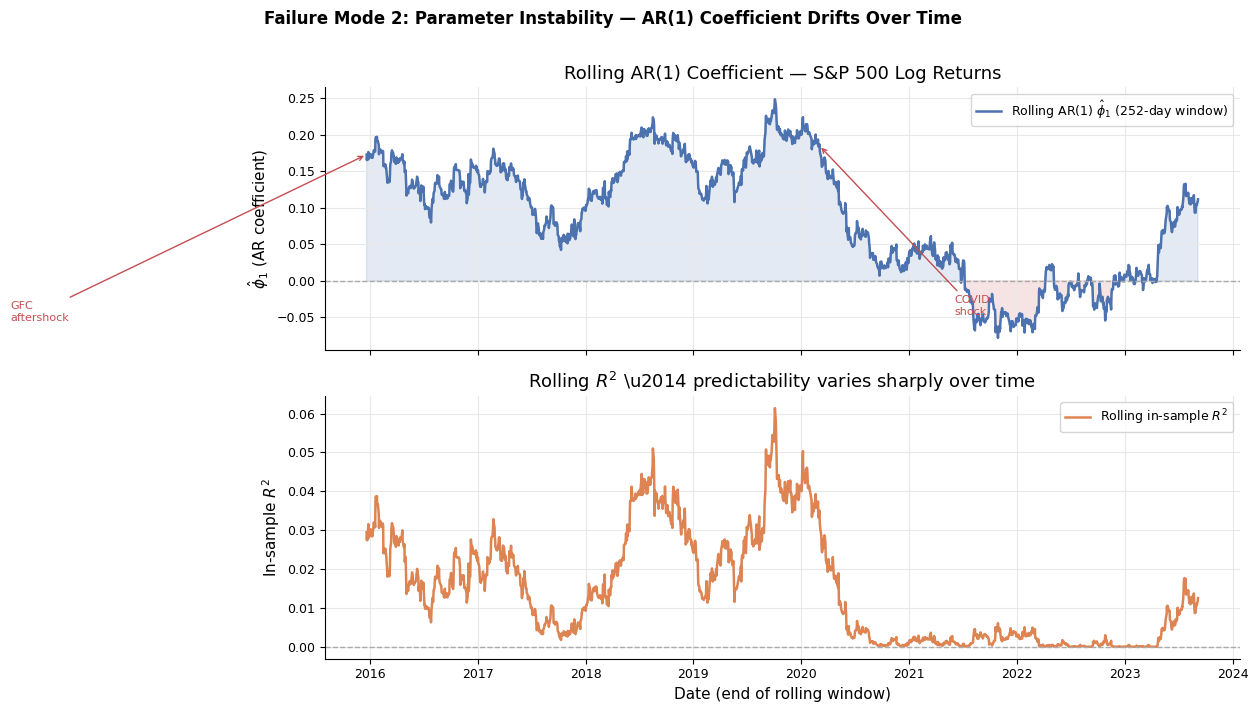

Rolling phi_1 — mean: 0.0896  |  std: 0.0802
Rolling phi_1 — range: [-0.0784, 0.2487]

Implication: a model fit on one period may have very different parameters than
a model fit on another period — even for the same series.


In [27]:
# ── Failure Mode 2: Parameter Instability ─────────────────────────────────
# Estimate rolling AR(1) phi coefficient; show how it drifts over time

log_ret  = df['log_ret'].values
dates_r  = df.index
n        = len(log_ret)
win      = 252   # 1 year of trading days

phi_rolling  = []
r2_rolling   = []
date_rolling = []

for t in range(win, n - 1):
    y_w = log_ret[t - win + 1: t + 1]
    X_w = log_ret[t - win: t].reshape(-1, 1)
    m_w = LinearRegression().fit(X_w, y_w)
    phi_rolling.append(m_w.coef_[0])
    r2_rolling.append(m_w.score(X_w, y_w))
    date_rolling.append(dates_r[t])

phi_rolling  = np.array(phi_rolling)
r2_rolling   = np.array(r2_rolling)
date_rolling = np.array(date_rolling)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1]})

# Panel 1: rolling phi_1
ax = axes[0]
ax.plot(date_rolling, phi_rolling, color=COLORS['train'], lw=1.8,
        label=r'Rolling AR(1) $\hat{\phi}_1$ (252-day window)')
ax.axhline(0, color='#aaaaaa', lw=1, ls='--')
ax.fill_between(date_rolling, phi_rolling, 0,
                where=phi_rolling > 0, alpha=0.15, color=COLORS['train'])
ax.fill_between(date_rolling, phi_rolling, 0,
                where=phi_rolling < 0, alpha=0.15, color=COLORS['forecast'])
ax.set_ylabel(r'$\hat{\phi}_1$ (AR coefficient)')
ax.set_title('Rolling AR(1) Coefficient \u2014 S&P 500 Log Returns')
ax.legend(fontsize=9)

# Add annotations at notable shifts
def nearest_idx(dates_arr, target):
    return np.argmin(np.abs(np.array(dates_arr, dtype='datetime64[ns]')
                             - np.datetime64(target, 'ns')))

gfc_i = nearest_idx(date_rolling, '2011-08-01')
cov_i = nearest_idx(date_rolling, '2020-03-01')

ax.annotate('GFC\naftershock',
    xy=(date_rolling[gfc_i], phi_rolling[gfc_i]),
    xytext=(pd.Timestamp('2012-09-01'), phi_rolling.min() * 0.7),
    fontsize=8, color=COLORS['forecast'],
    arrowprops=dict(arrowstyle='->', color=COLORS['forecast']))
ax.annotate('COVID\nshock',
    xy=(date_rolling[cov_i], phi_rolling[cov_i]),
    xytext=(pd.Timestamp('2021-06-01'), phi_rolling.min() * 0.6),
    fontsize=8, color=COLORS['forecast'],
    arrowprops=dict(arrowstyle='->', color=COLORS['forecast']))

# Panel 2: rolling R2
axes[1].plot(date_rolling, r2_rolling, color=COLORS['val'], lw=1.8,
             label=r'Rolling in-sample $R^2$')
axes[1].axhline(0, color='#aaaaaa', lw=1, ls='--')
axes[1].set_ylabel(r'In-sample $R^2$')
axes[1].set_xlabel('Date (end of rolling window)')
axes[1].set_title(r'Rolling $R^2$ \u2014 predictability varies sharply over time')
axes[1].legend(fontsize=9)

fig.suptitle('Failure Mode 2: Parameter Instability \u2014 AR(1) Coefficient Drifts Over Time',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Rolling phi_1 \u2014 mean: {phi_rolling.mean():.4f}  |  std: {phi_rolling.std():.4f}')
print(f'Rolling phi_1 \u2014 range: [{phi_rolling.min():.4f}, {phi_rolling.max():.4f}]')
print()
print('Implication: a model fit on one period may have very different parameters than')
print('a model fit on another period \u2014 even for the same series.')

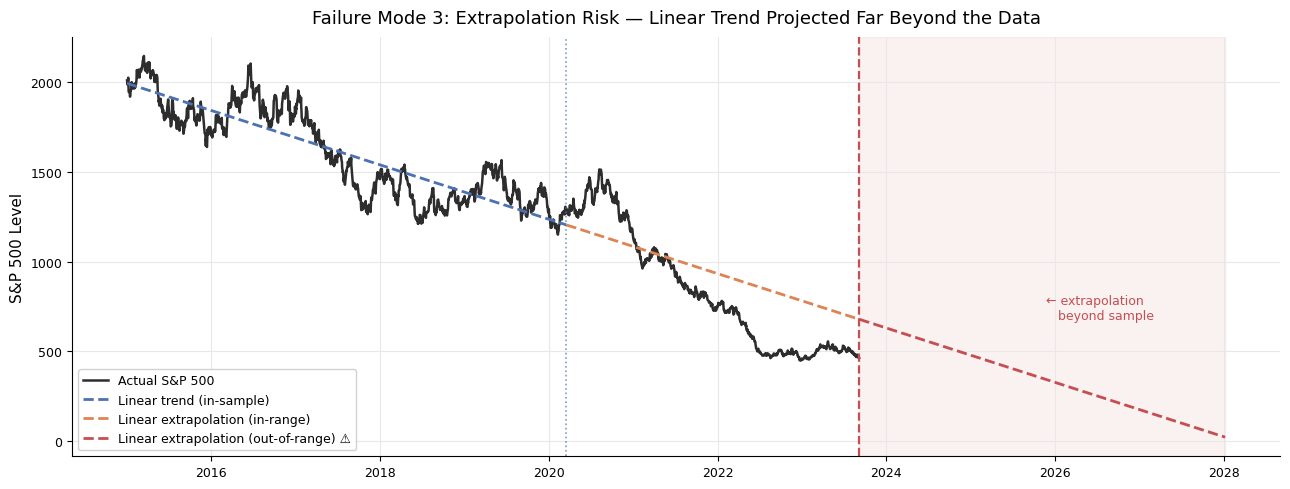

Extrapolation risk: the model has no information about what happens beyond the sample.
Linear trends, exponential fits, or any parametric model can produce
implausible forecasts when extended far outside the historical range.


In [28]:
# ── Failure Mode 3: Extrapolation Risk ────────────────────────────────────
# Fit a simple trend model on S&P 500 levels, extrapolate well beyond sample

price    = df['SP500'].values
dates_p  = df.index
n_p      = len(price)
t_idx    = np.arange(n_p)

# Fit linear trend on first 60% of data
n_tr2 = int(n_p * 0.6)
m_trend = np.polyfit(t_idx[:n_tr2], price[:n_tr2], 1)

# Extrapolate to 150% of sample length
t_extrap = np.arange(int(n_p * 1.5))
price_extrap = np.polyval(m_trend, t_extrap)
extrap_dates = pd.date_range(dates_p[0], periods=len(t_extrap), freq='B')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_p, price, color=COLORS['actual'], lw=1.8, label='Actual S&P 500')
ax.plot(extrap_dates[:n_tr2], price_extrap[:n_tr2],
        color=COLORS['train'], lw=2, ls='--', label='Linear trend (in-sample)')
ax.plot(extrap_dates[n_tr2:n_p], price_extrap[n_tr2:n_p],
        color=COLORS['val'], lw=2, ls='--', label='Linear extrapolation (in-range)')
ax.plot(extrap_dates[n_p:], price_extrap[n_p:],
        color=COLORS['forecast'], lw=2, ls='--', label='Linear extrapolation (out-of-range) ⚠')

ax.axvspan(extrap_dates[n_p], extrap_dates[-1], alpha=0.08, color=COLORS['forecast'])
ax.axvline(extrap_dates[n_tr2], color=COLORS['train'], lw=1.2, ls=':', alpha=0.7)
ax.axvline(extrap_dates[n_p],   color=COLORS['forecast'], lw=1.6, ls='--')
ax.text(extrap_dates[n_p + len(t_extrap[n_p:])//2], price_extrap[n_p],
        ' ← extrapolation\n    beyond sample', fontsize=9, color=COLORS['forecast'])

ax.set_ylabel('S&P 500 Level')
ax.set_title('Failure Mode 3: Extrapolation Risk — Linear Trend Projected Far Beyond the Data', pad=10)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print('Extrapolation risk: the model has no information about what happens beyond the sample.')
print('Linear trends, exponential fits, or any parametric model can produce')
print('implausible forecasts when extended far outside the historical range.')

---
## Summary

Today we moved from *describing the past* to *predicting the future honestly*.

| Concept | Core idea | Practical rule |
|---------|-----------|----------------|
| **Out-of-sample forecasting** | Evaluate only on data the model never saw | Never touch the test set until the very end |
| **Data leakage** | Future info in training → falsely good metrics | Always split time series chronologically |
| **Overfitting** | Model memorises noise, not signal | Watch the train–test RMSE gap |
| **Underfitting** | Model too simple to capture signal | High error on both train and test |
| **Rolling window** | Fixed-size training window slides forward | Use when relationships shift over time |
| **Expanding window** | Training grows as data accumulates | Use when more data is always better |
| **Time-series K-fold** | Validation folds always come after training | Use `TimeSeriesSplit`, never random K-fold |
| **Block bootstrap** | Resample blocks to preserve dependence | Gives honest forecast intervals without normality |
| **Regime change** | Historical patterns break → spikes in rolling RMSE | Monitor RMSE over time; detect early |
| **Parameter instability** | Coefficients drift across periods | Rolling estimation reveals structural shifts |
| **Extrapolation risk** | Model asked to predict outside training range | Flag forecasts far from historical norms |

### What comes next

With validation and overfitting fully in hand, we turn to the structure of the series itself.  
The cliffhanger from Lecture 1.5 still stands: S&P 500 log returns look close to white noise — but many economic and financial series have **persistent seasonal structure**.

Next lecture: **Cyclical Time Series and Deseasonalization.**